Behavior shape: (421627, 12)

Behavior columns:
['session', 'timestamp', 'block type', 'MoSeq syllable', 'shMoSeq state', 'subject centroid (x)', 'subject centroid (y)', 'subject heading', 'conspecific centroid (x)', 'conspecific centroid (y)', 'distance to wall', 'wall direction']


,session,timestamp,block type,MoSeq syllable,shMoSeq state,subject centroid (x),subject centroid (y),subject heading,conspecific centroid (x),conspecific centroid (y),distance to wall,wall direction
0,subject0_recording0,0.000000,no conspecific,0,0.0,309.448825,164.898594,132.260686,NaN,NaN,22.390722,-0.642794
1,subject0_recording0,0.033333,no conspecific,0,0.0,309.448825,165.662242,132.639031,NaN,NaN,23.911470,-0.637264
2,subject0_recording0,0.066667,no conspecific,0,0.0,309.448825,166.746835,132.711213,NaN,NaN,24.766056,-0.635628
3,subject0_recording0,0.100000,no conspecific,3,0.0,309.448825,167.899166,132.757347,NaN,NaN,25.515665,-0.634290
4,subject0_recording0,0.133333,no conspecific,3,0.0,309.241923,168.691210,132.870937,NaN,NaN,26.649155,-0.633201


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
session,421627,4,subject2_recording0,106315,NaN,NaN,NaN,NaN,NaN,NaN,NaN
timestamp,421627.0,NaN,NaN,NaN,1757.071212,1014.807277,0.0,878.366667,1756.766667,2635.15,3543.8
block type,421627,4,no conspecific,140129,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MoSeq syllable,421627.0,NaN,NaN,NaN,25.671847,13.225161,0.0,19.0,23.0,39.0,49.0
shMoSeq state,404287.0,NaN,NaN,NaN,1.912325,1.10622,0.0,1.0,2.0,3.0,3.0
subject centroid (x),421627.0,NaN,NaN,NaN,210.158983,143.523357,0.0,109.234809,118.042857,354.578301,474.230228
subject centroid (y),421627.0,NaN,NaN,NaN,322.382335,160.547856,0.0,162.148079,262.278501,498.167817,524.970308
subject heading,421627.0,NaN,NaN,NaN,-3407.738129,3509.466728,-12351.219394,-5339.767345,-3453.174113,1.568971,2317.890029
conspecific centroid (x),272929.0,NaN,NaN,NaN,290.719981,131.114784,91.071464,150.272443,303.195871,429.890312,471.592724
conspecific centroid (y),272929.0,NaN,NaN,NaN,348.749033,139.94612,144.026849,190.325,380.793597,492.421529,521.906498


conspecific centroid (x)    0.352677
conspecific centroid (y)    0.352677
shMoSeq state               0.041126
session                     0.000000
MoSeq syllable              0.000000
block type                  0.000000
timestamp                   0.000000
subject centroid (x)        0.000000
subject heading             0.000000
subject centroid (y)        0.000000
distance to wall            0.000000
wall direction              0.000000
dtype: float64

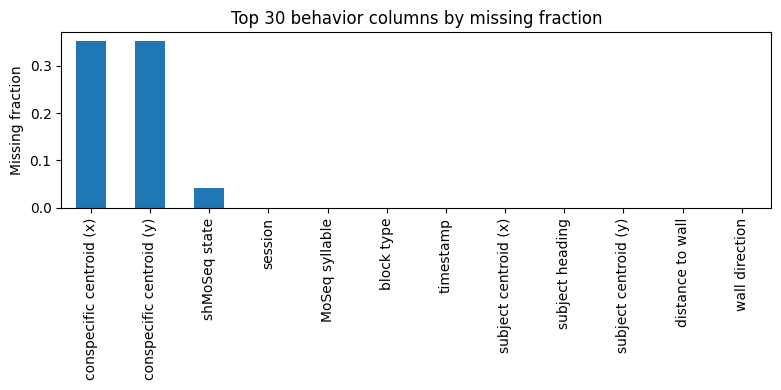

H5 structure:
DATASET: subject0_recording0, shape=(106272, 729), dtype=float32
DATASET: subject1_recording0, shape=(106047, 491), dtype=float32
DATASET: subject2_recording0, shape=(106315, 175), dtype=float32
DATASET: subject3_recording0, shape=(102993, 376), dtype=float32


In [1]:
# =========================================
# 0. Imports
# =========================================
import pandas as pd
import numpy as np
import h5py
import matplotlib.pyplot as plt

from pathlib import Path

# Optional
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


# =========================================
# 1. Paths
# =========================================
behavior_path = Path("/home/maria/Science/data/spontaneous_behaviors/aggression-behavior.parquet")
neural_path   = Path("/home/maria/Science/data/spontaneous_behaviors/aggression-neural.h5")


# =========================================
# 2. Load behavior data
# =========================================
behavior = pd.read_parquet(behavior_path)

print("Behavior shape:", behavior.shape)
print("\nBehavior columns:")
print(behavior.columns.tolist())

display(behavior.head())
display(behavior.describe(include="all").T.head(50))


# =========================================
# 3. Inspect behavior missingness
# =========================================
missing_behavior = behavior.isna().mean().sort_values(ascending=False)
display(missing_behavior.head(30))

plt.figure(figsize=(8, 4))
missing_behavior.head(30).plot(kind="bar")
plt.title("Top 30 behavior columns by missing fraction")
plt.ylabel("Missing fraction")
plt.tight_layout()
plt.show()


# =========================================
# 4. Load neural H5 structure
# =========================================
def print_h5_structure(name, obj):
    if isinstance(obj, h5py.Dataset):
        print(f"DATASET: {name}, shape={obj.shape}, dtype={obj.dtype}")
    else:
        print(f"GROUP:   {name}")

with h5py.File(neural_path, "r") as f:
    print("H5 structure:")
    f.visititems(print_h5_structure)

In [4]:
import h5py

def print_h5_structure(name, obj):
    if isinstance(obj, h5py.Dataset):
        print(f"DATASET: {name}, shape={obj.shape}, dtype={obj.dtype}")
    else:
        print(f"GROUP:   {name}")

with h5py.File(neural_path, "r") as f:
    f.visititems(print_h5_structure)

DATASET: subject0_recording0, shape=(106272, 729), dtype=float32
DATASET: subject1_recording0, shape=(106047, 491), dtype=float32
DATASET: subject2_recording0, shape=(106315, 175), dtype=float32
DATASET: subject3_recording0, shape=(102993, 376), dtype=float32


In [7]:
import pandas as pd

behavior = pd.read_parquet(behavior_path)

print("Behavior shape:", behavior.shape)
print("\nColumns:")
print(behavior.columns.tolist())

print("\nHead:")
display(behavior.head())

print("\nPotential subject/recording columns:")
for c in behavior.columns:
    lc = c.lower()
    if "subject" in lc or "record" in lc or "session" in lc or "mouse" in lc:
        print(c, behavior[c].drop_duplicates().tolist()[:20])

print("\nNumber of rows:", len(behavior))

Behavior shape: (421627, 12)

Columns:
['session', 'timestamp', 'block type', 'MoSeq syllable', 'shMoSeq state', 'subject centroid (x)', 'subject centroid (y)', 'subject heading', 'conspecific centroid (x)', 'conspecific centroid (y)', 'distance to wall', 'wall direction']

Head:


,session,timestamp,block type,MoSeq syllable,shMoSeq state,subject centroid (x),subject centroid (y),subject heading,conspecific centroid (x),conspecific centroid (y),distance to wall,wall direction
0,subject0_recording0,0.000000,no conspecific,0,0.0,309.448825,164.898594,132.260686,NaN,NaN,22.390722,-0.642794
1,subject0_recording0,0.033333,no conspecific,0,0.0,309.448825,165.662242,132.639031,NaN,NaN,23.911470,-0.637264
2,subject0_recording0,0.066667,no conspecific,0,0.0,309.448825,166.746835,132.711213,NaN,NaN,24.766056,-0.635628
3,subject0_recording0,0.100000,no conspecific,3,0.0,309.448825,167.899166,132.757347,NaN,NaN,25.515665,-0.634290
4,subject0_recording0,0.133333,no conspecific,3,0.0,309.241923,168.691210,132.870937,NaN,NaN,26.649155,-0.633201



Potential subject/recording columns:
session ['subject0_recording0', 'subject1_recording0', 'subject2_recording0', 'subject3_recording0']
subject centroid (x) [309.4488248673237, 309.24192336589033, 308.711877394636, 308.17040358744396, 307.3820224719101, 306.53395061728395, 305.74591381872216, 308.16358463726885, 310.98453261600537, 314.3124191461837, 318.4695160276556, 324.0470588235294, 329.23992443324937, 334.1180387409201, 340.24039653035936, 345.6492082825822, 350.626902008521, 356.1500926497838, 359.9801154586273, 363.2633612363168]
subject centroid (y) [164.89859363434493, 165.6622418879056, 166.74683544303798, 167.8991660348749, 168.69120961682944, 169.4015325670498, 170.2204783258595, 170.87865168539327, 170.55810397553518, 169.36181277860328, 167.0419630156472, 165.1439139206456, 163.41655886157827, 161.83469516027657, 160.34901960784313, 158.2581863979849, 156.13861985472155, 154.2001239157373, 153.50426309378807, 153.27486102532427]
subject heading [132.2606864943302, 132

In [8]:
import h5py

with h5py.File(neural_path, "r") as f:
    for key in f.keys():
        print(key, f[key].shape)

dataset_key = "subject3_recording0"   # example only

with h5py.File(neural_path, "r") as f:
    neural = f[dataset_key][:]

print(neural.shape)

subject0_recording0 (106272, 729)
subject1_recording0 (106047, 491)
subject2_recording0 (106315, 175)
subject3_recording0 (102993, 376)
(102993, 376)


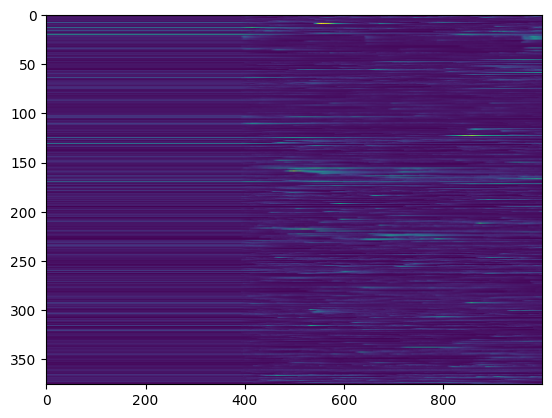

In [12]:
plt.imshow(neural[:1000].T, aspect='auto')

In [13]:
neural

array([[-0.44753924, -0.71034366, -0.49988624, ...,  0.58290356,
        -0.6968207 , -0.9256265 ],
       [-0.44753924, -0.71034366, -0.49988624, ...,  0.58290356,
        -0.6968207 , -0.9256265 ],
       [-0.44753924, -0.71034366, -0.49988624, ...,  0.58290356,
        -0.6968207 , -0.9256265 ],
       ...,
       [-0.9355317 , -0.6716744 , -0.63136274, ...,  0.35285926,
         0.6958362 , -0.52714777],
       [-0.95658946, -0.6733993 , -0.6605194 , ...,  0.30667987,
         0.5976312 , -0.5480806 ],
       [-0.9761196 , -0.67504734, -0.68748087, ...,  0.338675  ,
         0.50415623, -0.56810707]], shape=(102993, 376), dtype=float32)

In [14]:
col_means = neural.mean(axis=0)
col_stds = neural.std(axis=0)

print("mean of column means:", col_means.mean())
print("std of column means:", col_means.std())

print("mean of column stds:", col_stds.mean())
print("std of column stds:", col_stds.std())

mean of column means: 0.00041779518
std of column means: 0.007358071
mean of column stds: 1.0042217
std of column stds: 0.0187733


[-0.0072643   0.00410624  0.00866487 -0.00905487 -0.00652767  0.00667517
 -0.00178991 -0.00704074  0.01954369 -0.00720701]
[0.9897314 1.0210998 1.0132455 0.9882844 0.9812746 1.009291  1.0050833
 0.9876877 1.0333997 0.9893487]


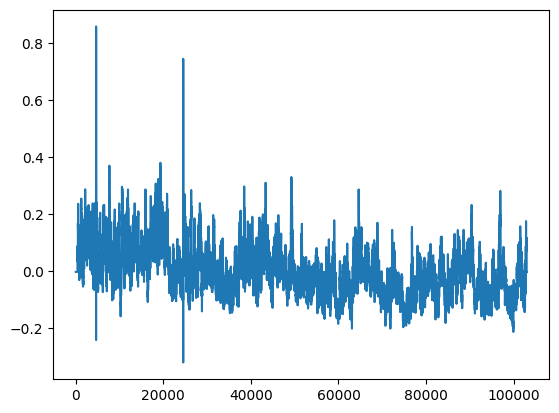

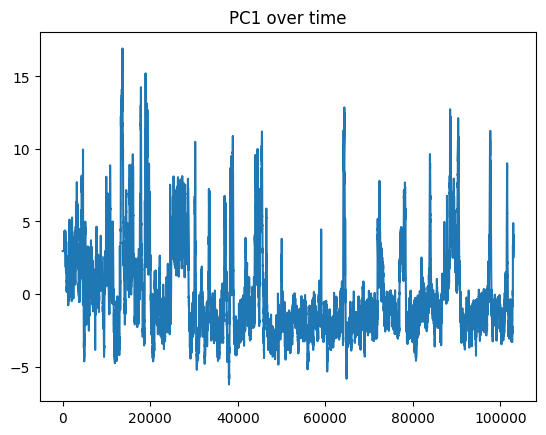

In [16]:
# 1. verify z-scoring
print(neural.mean(axis=0)[:10])
print(neural.std(axis=0)[:10])

# 2. look at population mean over time
pop_mean = neural.mean(axis=1)
plt.plot(pop_mean)
plt.show()
# 3. PCA
from sklearn.decomposition import PCA
Z = PCA(n_components=5).fit_transform(neural)
plt.plot(Z[:, 0])
plt.title("PC1 over time")
plt.show()

   timestamp  inter_mouse_distance
0   0.000000                   NaN
1   0.033333                   NaN
2   0.066667                   NaN
3   0.100000                   NaN
4   0.133333                   NaN
(106315, 2)


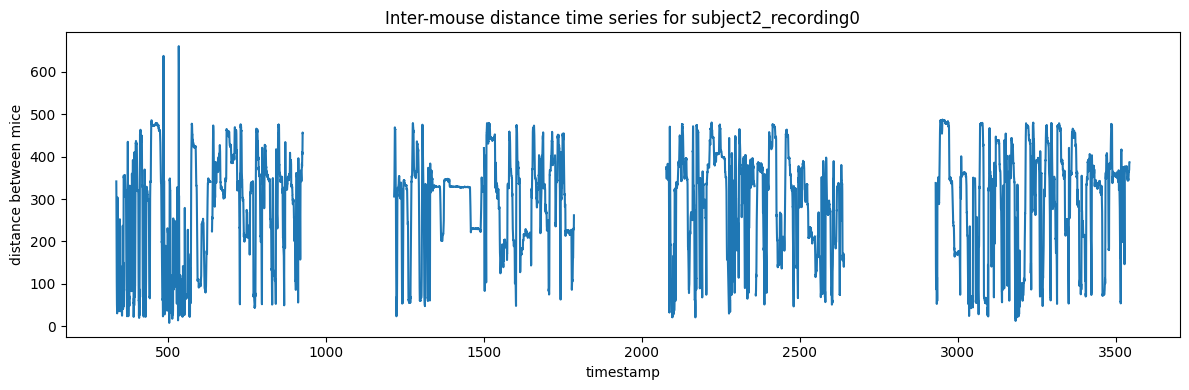

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# load
behavior = pd.read_parquet(behavior_path)

# keep only subject_2 session
subject2 = (
    behavior.loc[behavior["session"] == "subject2_recording0"]
    .copy()
    .sort_values("timestamp")
    .reset_index(drop=True)
)

# compute subject-conspecific distance
subject2["inter_mouse_distance"] = np.sqrt(
    (subject2["subject centroid (x)"] - subject2["conspecific centroid (x)"]) ** 2
    + (subject2["subject centroid (y)"] - subject2["conspecific centroid (y)"]) ** 2
)

# a compact time series dataframe
distance_ts = subject2[["timestamp", "inter_mouse_distance"]].copy()

print(distance_ts.head())
print(distance_ts.shape)

# plot
plt.figure(figsize=(12, 4))
plt.plot(distance_ts["timestamp"], distance_ts["inter_mouse_distance"])
plt.xlabel("timestamp")
plt.ylabel("distance between mice")
plt.title("Inter-mouse distance time series for subject2_recording0")
plt.tight_layout()
plt.show()

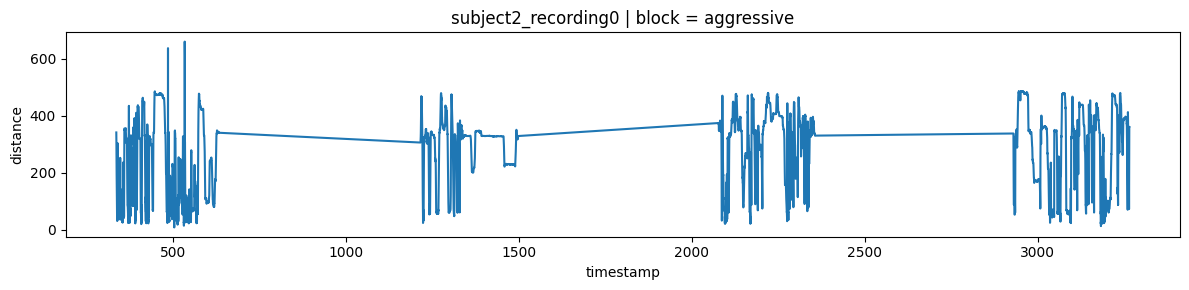

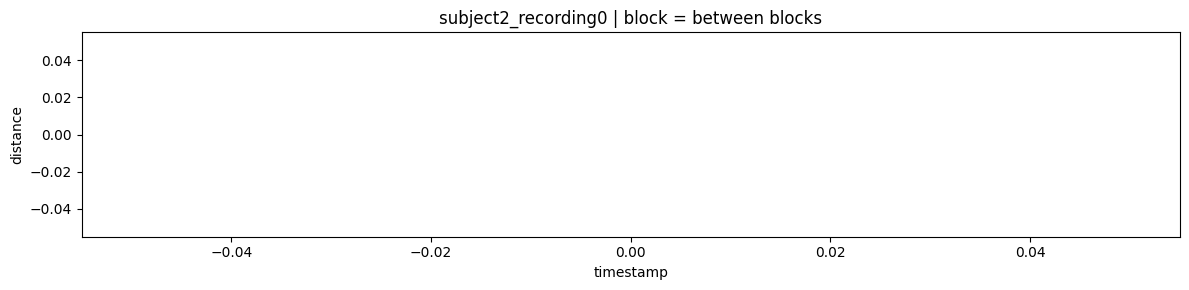

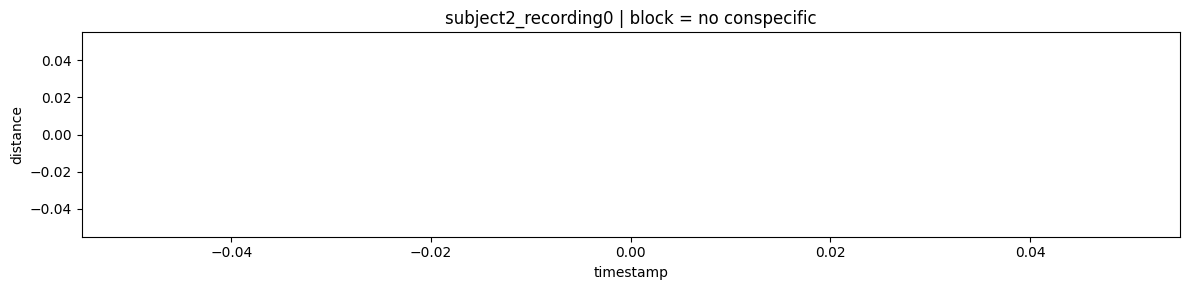

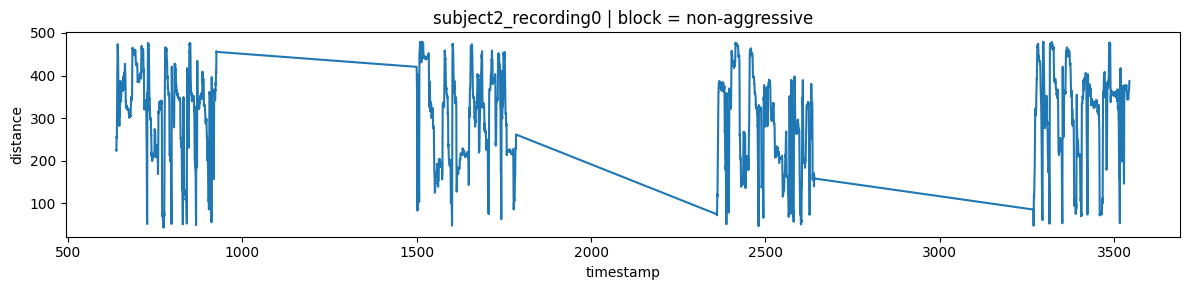

In [32]:
for block_name, g in subject2.groupby("block type"):
    g = g.sort_values("timestamp")
    plt.figure(figsize=(12, 3))
    plt.plot(g["timestamp"], g["inter_mouse_distance"])
    plt.title(f"subject2_recording0 | block = {block_name}")
    plt.xlabel("timestamp")
    plt.ylabel("distance")
    plt.tight_layout()
    plt.show()

               session   timestamp      block type  inter_mouse_distance
0  subject2_recording0  331.266667  between blocks                   NaN
1  subject2_recording0  331.300000  between blocks                   NaN
2  subject2_recording0  331.333333  between blocks                   NaN
3  subject2_recording0  331.366667  between blocks                   NaN
4  subject2_recording0  331.400000  between blocks                   NaN


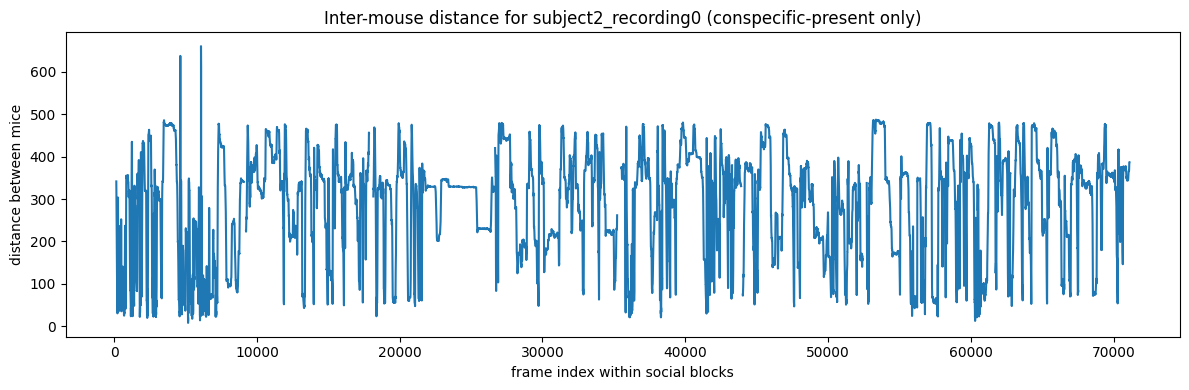

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

behavior = pd.read_parquet(behavior_path)

subject2_social = (
    behavior.loc[
        (behavior["session"] == "subject2_recording0") &
        (behavior["block type"] != "no conspecific")
    ]
    .copy()
    .sort_values("timestamp")
    .reset_index(drop=True)
)

subject2_social["inter_mouse_distance"] = np.sqrt(
    (subject2_social["subject centroid (x)"] - subject2_social["conspecific centroid (x)"]) ** 2
    + (subject2_social["subject centroid (y)"] - subject2_social["conspecific centroid (y)"]) ** 2
)

subject2_social["frame_idx"] = np.arange(len(subject2_social))

print(subject2_social[[
    "session", "timestamp", "block type", "inter_mouse_distance"
]].head())

plt.figure(figsize=(12, 4))
plt.plot(subject2_social["frame_idx"], subject2_social["inter_mouse_distance"])
plt.xlabel("frame index within social blocks")
plt.ylabel("distance between mice")
plt.title("Inter-mouse distance for subject2_recording0 (conspecific-present only)")
plt.tight_layout()
plt.show()

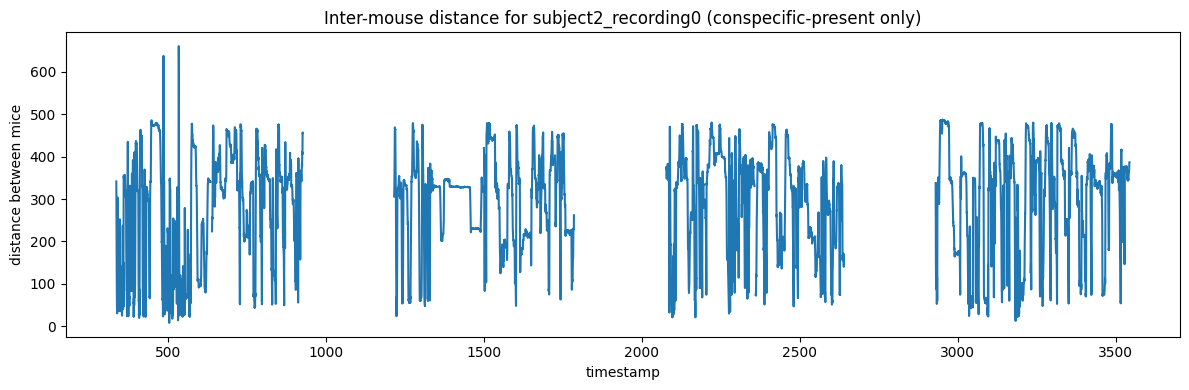

In [34]:
plt.figure(figsize=(12, 4))
plt.plot(subject2_social["timestamp"], subject2_social["inter_mouse_distance"])
plt.xlabel("timestamp")
plt.ylabel("distance between mice")
plt.title("Inter-mouse distance for subject2_recording0 (conspecific-present only)")
plt.tight_layout()
plt.show()

In [35]:
print(
    behavior.loc[behavior["session"] == "subject2_recording0", "block type"]
    .value_counts(dropna=False)
)

block type
aggressive        35841
no conspecific    35194
non-aggressive    33793
between blocks     1487
Name: count, dtype: int64
